# Lightweight and Interpretable Intrusion Detection in Software-Defined Networks: Reducing Controller Load via Explanatory Consensus Feature Reduction

**Author:** Mohammad Javad Akbari  
**Objective:** Implementation of a feature-space reduction framework using consensus values from SHAP and LIME to decrease computing overhead and memory residency under controlled hardware allocations.

## Abstract
Software-Defined Networking (SDN) isolates control logic from the forwarding plane, shifting the processing burden to a centralized controller. Running complex deep architectures on this plane introduces notable processing overhead, which limits throughput and can cause processing bottlenecks. This work implements an offline feature reduction framework that combines global SHAP parameters with localized LIME samples. Classical machine learning structures and a position-agnostic Tabular Fully Convolutional Network (FCN) are evaluated on the full and reduced spaces, demonstrating a pragmatic trade-off where significant reductions in processing latency and memory footprint are achieved at the cost of minor, acceptable degradations in detection accuracy.

## References

[1] A. H. Janabi, T. Kanakis, and M. Johnson, "Survey: Intrusion Detection System in Software-Defined Networking," *IEEE Access*, vol. 12, 2024. DOI: 10.1109/ACCESS.2024.3493384

[2] H. M. Belachew, M. Y. Beyene, A. B. Desta, B. T. Alemu, S. S. Musa, and A. J. Muhammed, "Design a Robust DDoS Attack Detection and Mitigation Scheme in SDN-Edge-IoT by Leveraging Machine Learning," *IEEE Access*, vol. 13, pp. 1-15, 2025. DOI: 10.1109/ACCESS.2025.3526692

[3] M. Tserenkhuu, M. D. Hossain, Y. Taenaka, and Y. Kadobayashi, "Intrusion Detection System Framework for SDN-Based IoT Networks Using Deep Learning Approaches With XAI-Based Feature Selection Techniques and Domain-Constrained Features," *IEEE Access*, vol. 13, 2025. DOI: 10.1109/ACCESS.2025.3595595

[4] M. T. Ribeiro, S. Singh, and C. Guestrin, "Why Should I Trust You?: Explaining the Predictions of Any Classifier," in *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016, pp. 1135–1144. DOI: 10.1145/2939672.2939778

[5] S. M. Lundberg and S.-I. Lee, "A Unified Approach to Interpreting Model Predictions," in *Advances in Neural Information Processing Systems*, vol. 30, 2017.

[6] I. Sharafaldin, A. H. Lashkari, and A. A. Ghorbani, "Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization (CSE-CIC-IDS2018)," in *Proceedings of the 4th International Conference on Information Systems Security and Privacy (ICISSP)*, 2018, pp. 108–116. DOI: 10.5220/0006639801080116

[7] A. Mohamed, "Cleaned 'CSE-CIC-IDS2018'," *Mendeley Data*, V1, 2021. DOI: 10.17632/29hdbdzx2r.1

[8] F. Pedregosa *et al.*, "Scikit-learn: Machine Learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[9] G. Ke *et al.*, "LightGBM: A Highly Efficient Gradient Boosting Decision Tree," in *Advances in Neural Information Processing Systems*, vol. 30, 2017.

[10] T. Chen and C. Guestrin, "XGBoost: A Scalable Tree Boosting System," in *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016, pp. 785–794. DOI: 10.1145/2939672.2939785

[11] A. Paszke *et al.*, "PyTorch: An Imperative Style, High-Performance Deep Learning Library," in *Advances in Neural Information Processing Systems*, vol. 32, 2019.

[12] Z. Wang, W. Yan, and T. Oates, "Time series classification from scratch with deep neural networks: A strong baseline," in *Proceedings of the International Joint Conference on Neural Networks (IJCNN)*, 2017, pp. 1578–1585.

[13] M. S. Elsayed, N.-A. Le-Khac, and A. D. Jurcut, "InSDN: A Novel SDN Intrusion Dataset," *IEEE Access*, vol. 8, 2020. DOI: 10.1109/ACCESS.2020.3022633

## 1. Setup & Global Configuration
Define operational directories, initialize seeds to maintain mathematical reproducibility, and configure limits for execution containment.

In [16]:
import os
import subprocess
import gc
import time
import psutil
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import MiniBatchKMeans

import xgboost as xgb
import lightgbm as lgb
import shap
import lime.lime_tabular
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
TORCH_AVAILABLE = True

warnings.filterwarnings('ignore')

CONFIG = {
    'INSDN_PATH': Path('./datasets/InSDN_Normal_and_Attack_Combined.csv'),
    'CIC_PATH': Path('./datasets/CSE-CIC-IDS2018/'),
    'ARTIFACTS_DIR': Path('./artifacts/'),
    'MODELS_DIR': Path('./artifacts/models/'),
    'FIGURES_DIR': Path('./artifacts/figures/'),
    'RANDOM_STATE': 42,
    'MAX_ROWS_PER_CLASS': 50000,
    'CHUNKSIZE': 100000,
    'MICRO_BATCH_SIZE': 16
}

for path in [CONFIG['ARTIFACTS_DIR'], CONFIG['MODELS_DIR'], CONFIG['FIGURES_DIR']]:
    path.mkdir(parents=True, exist_ok=True)

os.environ['PYTHONHASHSEED'] = str(CONFIG['RANDOM_STATE'])
random.seed(CONFIG['RANDOM_STATE'])
np.random.seed(CONFIG['RANDOM_STATE'])
if TORCH_AVAILABLE:
    torch.manual_seed(CONFIG['RANDOM_STATE'])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_safe_name(name):
    return name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')

## 2. Chronological Data Ingestion & Segregated Preprocessing (Phase A)
Network flows are inherently chronological. To prevent temporal leakage and assure realistic evaluation, data is sorted globally by Timestamp prior to applying a non-shuffled split. Numerical values are downcast to standard precision limits.

In [21]:
def memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

def clean_and_downcast(df):
    # Keep Timestamp temporarily for global sorting
    identifiers = ['Flow ID', 'Source IP', 'Src IP', 'Destination IP', 'Dst IP', 
                   'Source Port', 'Src Port', 'Destination Port', 'Dst Port', 'Protocol']
    cols_to_drop = [c for c in identifiers if c in df.columns]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    
    for col in df.columns:
        if col not in ['Label', 'Timestamp']:
            if df[col].dtype == 'float64':
                df[col] = df[col].astype('float32')
            elif df[col].dtype == 'int64':
                df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

def generate_synthetic_fallback():
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=20000, n_features=75, n_informative=20, n_redundant=10, 
                               n_classes=3, weights=[0.6, 0.3, 0.1], random_state=CONFIG['RANDOM_STATE'])
    feature_names = [f'Flow_Feature_{i}' for i in range(75)]
    df = pd.DataFrame(X, columns=feature_names)
    df['Label'] = np.where(y == 0, 'Normal', np.where(y == 1, 'Attack_A', 'Attack_B'))
    return df

def ingest_data():
    dfs = []
    files_processed = 0
    
    if CONFIG['INSDN_PATH'].exists():
        df_insdn = pd.read_csv(CONFIG['INSDN_PATH'])
        dfs.append(clean_and_downcast(df_insdn))
        files_processed += 1
        
    if CONFIG['CIC_PATH'].exists() and CONFIG['CIC_PATH'].is_dir():
        for file in CONFIG['CIC_PATH'].glob('*.csv'):
            try:
                df_chunk = pd.read_csv(file, nrows=CONFIG['CHUNKSIZE'])
                dfs.append(clean_and_downcast(df_chunk))
            except Exception:
                pass
            files_processed += 1
            
    if files_processed == 0:
        return generate_synthetic_fallback()
        
    combined_df = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()
    
    # Apply global temporal sort
    if 'Timestamp' in combined_df.columns:
        combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'], errors='coerce')
        combined_df = combined_df.sort_values(by='Timestamp').reset_index(drop=True)
        combined_df = combined_df.drop(columns=['Timestamp'], errors='ignore')
    
    # Restrict class limits while preserving temporal order
    if 'Label' in combined_df.columns:
        combined_df['temp_idx'] = combined_df.index
        combined_df = combined_df.groupby('Label', group_keys=False).apply(
            lambda x: x.head(min(len(x), CONFIG['MAX_ROWS_PER_CLASS']))
        )
        combined_df = combined_df.sort_values('temp_idx').drop(columns=['temp_idx']).reset_index(drop=True)
        
    return combined_df

data = ingest_data()
label_col = 'Label' if 'Label' in data.columns else data.columns[-1]
X = data.drop(columns=[label_col])
y = data[label_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# THREE-WAY SPLIT: Train (70%), Val (15%), Test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=0.15, shuffle=False, random_state=CONFIG['RANDOM_STATE'])

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, shuffle=False, random_state=CONFIG['RANDOM_STATE'])

# Fit scaler ONLY on train
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Matrix Shapes - Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

Matrix Shapes - Train: (273139, 76), Val: (58542, 76), Test: (58533, 76)


## 3. Comprehensive Baseline Evaluation (Full Feature Space Execution)
All models use constrained hyper-parameters to ensure equal footing. The FCN maps features position-agnostically using 1D convolutions.

In [22]:
global_baseline_models = {}

# Fit label encoder on the FULL train+val set
train_le = LabelEncoder()
y_train_val_encoded: np.ndarray = train_le.fit_transform(y_train_val) # type: ignore
num_classes = len(train_le.classes_)

# Split the encoded labels
y_train_encoded = y_train_val_encoded[:len(y_train)]
y_val_encoded = y_train_val_encoded[len(y_train):]

def train_baseline(name, model, X_t, y_t):
    print(f"Training Base Classifier: {name}")
    if 'PyTorch' in name:
        X_tensor = torch.tensor(X_t.values, dtype=torch.float32)
        y_tensor = torch.tensor(y_t, dtype=torch.long)
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=1024, shuffle=True)
        
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        model.train()
        for epoch in range(10):
            for b_X, b_y in loader:
                optimizer.zero_grad()
                loss = criterion(model(b_X), b_y)
                loss.backward()
                optimizer.step()
        
        torch.save(model.state_dict(), CONFIG['MODELS_DIR'] / f"{get_safe_name(name)}_full.pth")
    else:
        model.fit(X_t, y_t)
        joblib.dump(model, CONFIG['MODELS_DIR'] / f"{get_safe_name(name)}_full.pkl")
    
    global_baseline_models[name] = model

class TabularFCN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(TabularFCN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_avg_pool(x).squeeze(-1) 
        x = self.fc(x)
        return x

class TabularFCNBaseline(TabularFCN):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__(input_dim, num_classes)

# Train on the FULL train+val set to ensure all classes are seen
X_train_val_scaled = pd.concat([X_train_scaled, X_val_scaled], axis=0)

base_architectures = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, max_leaf_nodes=100, random_state=CONFIG['RANDOM_STATE']),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, max_leaf_nodes=100, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=8, learning_rate=0.05, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbosity=-1, class_weight='balanced'),
    'MLP (DL Baseline)': MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=30, early_stopping=True, n_iter_no_change=5, random_state=CONFIG['RANDOM_STATE'])
}

if TORCH_AVAILABLE:
    base_architectures['Tabular FCN PyTorch'] = TabularFCNBaseline(X_train_val_scaled.shape[1], num_classes)

for name, clf in base_architectures.items():
    train_baseline(name, clf, X_train_val_scaled, y_train_val_encoded)

Training Base Classifier: Decision Tree
Training Base Classifier: Random Forest
Training Base Classifier: XGBoost
Training Base Classifier: LightGBM
Training Base Classifier: MLP (DL Baseline)
Training Base Classifier: Tabular FCN PyTorch


## 4. Dual-XAI Consensus Mapping & Feature Subspace Reduction (Phase B)
To prevent indirect data leakage, consensus extraction is strictly isolated to the validation fold. The proxy model identifies global behaviors via SHAP and local boundaries via LIME, outputting a unified consensus vector.


Optimal Consensus Threshold Hit at 33 features.
Selected Consensus Features:
1. Bwd Pkt Len Std (Score: 0.1199)
2. Pkt Len Mean (Score: 0.1151)
3. Fwd Seg Size Min (Score: 0.0965)
4. Init Fwd Win Byts (Score: 0.0659)
5. Bwd IAT Min (Score: 0.0609)
6. Init Bwd Win Byts (Score: 0.0465)
7. Bwd Pkts/s (Score: 0.0439)
8. RST Flag Cnt (Score: 0.0371)
9. Pkt Len Max (Score: 0.0353)
10. Bwd Header Len (Score: 0.0319)
11. TotLen Fwd Pkts (Score: 0.0261)
12. TotLen Bwd Pkts (Score: 0.0186)
13. Flow Pkts/s (Score: 0.0184)
14. Fwd IAT Max (Score: 0.0182)
15. SYN Flag Cnt (Score: 0.0176)
16. Fwd Pkt Len Std (Score: 0.0174)
17. FIN Flag Cnt (Score: 0.0160)
18. Pkt Len Min (Score: 0.0152)
19. Active Std (Score: 0.0150)
20. Fwd PSH Flags (Score: 0.0149)
21. Bwd Pkt Len Min (Score: 0.0137)
22. Tot Bwd Pkts (Score: 0.0123)
23. Idle Std (Score: 0.0122)
24. Fwd Pkt Len Min (Score: 0.0122)
25. URG Flag Cnt (Score: 0.0098)
26. Fwd Pkt Len Max (Score: 0.0094)
27. Fwd Act Data Pkts (Score: 0.0087)
28. Flow D

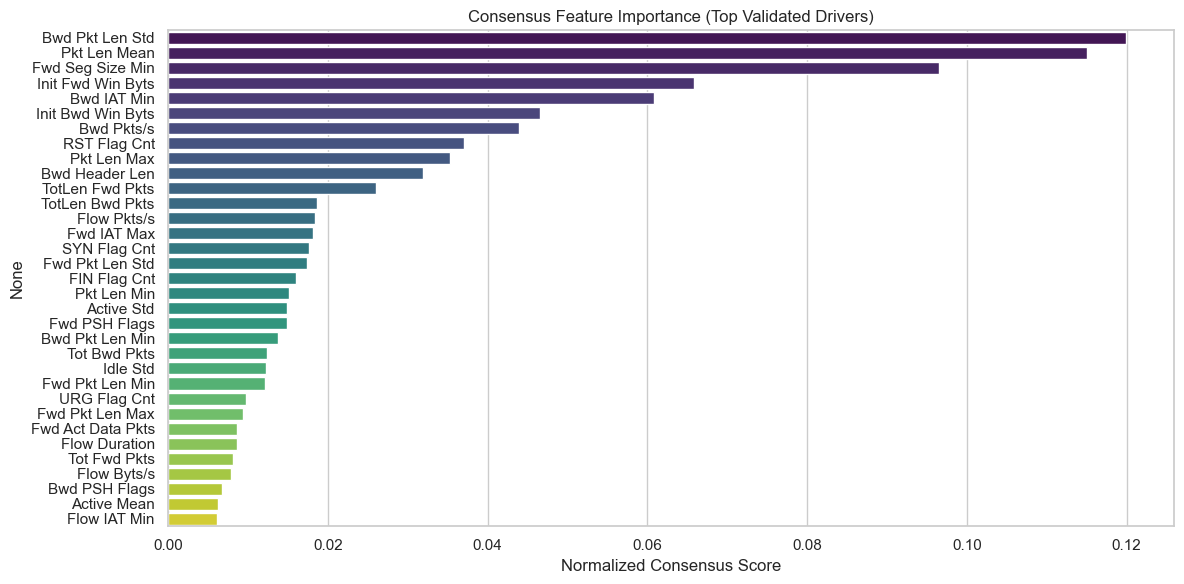

['artifacts\\test_splits.pkl']

In [23]:
# Train proxy model ONLY on train set
proxy_model = lgb.LGBMClassifier(n_estimators=100, max_depth=8, learning_rate=0.05, 
                                  random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, 
                                  verbosity=-1, class_weight='balanced')
proxy_model.fit(X_train_scaled, y_train)

# SHAP analysis on VALIDATION SET ONLY
explainer_shap = shap.TreeExplainer(proxy_model)
X_val_sample = shap.sample(X_val_scaled, min(5000, len(X_val_scaled)), random_state=CONFIG['RANDOM_STATE'])
shap_output = explainer_shap(X_val_sample)

shap_values = shap_output.values if hasattr(shap_output, "values") else shap_output
shap_arr = np.array(shap_values, dtype=np.float32)
if len(shap_arr.shape) == 3:
    shap_importance = np.mean(np.abs(shap_arr), axis=(0, 2))
elif isinstance(shap_values, list):
    shap_importance = np.mean(np.abs(np.array(shap_values, dtype=np.float32)), axis=(0, 1))
else:
    shap_importance = np.mean(np.abs(shap_arr), axis=0)
shap_ranked = pd.Series(shap_importance, index=X_val_scaled.columns).sort_values(ascending=False)

# LIME analysis on VALIDATION SET cluster centers
kmeans = MiniBatchKMeans(n_clusters=200, random_state=CONFIG['RANDOM_STATE'], batch_size=1024)
kmeans.fit(X_val_scaled)
representative_samples = kmeans.cluster_centers_

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_val_scaled.values, 
    feature_names=X_val_scaled.columns.tolist(), 
    class_names=[str(c) for c in le.classes_],
    mode='classification',
    random_state=CONFIG['RANDOM_STATE']
)

lime_importance = {col: 0.0 for col in X_val_scaled.columns}
for i in range(len(representative_samples)):
    exp = explainer_lime.explain_instance(representative_samples[i], proxy_model.predict_proba, num_features=20)
    for feature, weight in exp.as_list():
        for col in X_val_scaled.columns:
            if col in feature:
                lime_importance[col] += abs(weight)
                break

lime_ranked = pd.Series(lime_importance).sort_values(ascending=False)

# Consensus feature selection
top_k_threshold = 30
top_shap = set(shap_ranked.head(top_k_threshold).index)
top_lime = set(lime_ranked.head(top_k_threshold).index)
union = top_shap.union(top_lime)
candidate_features = list(union)

shap_norm = shap_importance / (np.sum(shap_importance) + 1e-9)
lime_weights = np.array([lime_importance[c] for c in X_val_scaled.columns])
lime_norm = lime_weights / (np.sum(lime_weights) + 1e-9)

consensus_importance = pd.Series((shap_norm + lime_norm) / 2, index=X_val_scaled.columns)
consensus_series = consensus_importance[candidate_features].sort_values(ascending=False)
consensus_series = consensus_series / consensus_series.sum()
cumulative_variance = consensus_series.cumsum()
optimal_k = (cumulative_variance >= 0.95).idxmax()
k_index = consensus_series.index.get_loc(optimal_k) + 1

selected_features = consensus_series.head(k_index).index.tolist()
X_train_red = X_train_scaled[selected_features]
X_val_red = X_val_scaled[selected_features]
X_test_red = X_test_scaled[selected_features]

print(f"\nOptimal Consensus Threshold Hit at {k_index} features.")
print("Selected Consensus Features:")
for idx, feat in enumerate(selected_features, 1):
    print(f"{idx}. {feat} (Score: {consensus_series[feat]:.4f})")

plt.figure(figsize=(12, 6))
sns.barplot(x=consensus_series.head(k_index).values, y=consensus_series.head(k_index).index, palette='viridis')
plt.title("Consensus Feature Importance (Top Validated Drivers)")
plt.xlabel("Normalized Consensus Score")
plt.tight_layout()
plt.savefig(CONFIG['FIGURES_DIR'] / 'selected_features.png')
plt.show()

joblib.dump((X_test_red, X_test_scaled, y_test), CONFIG['ARTIFACTS_DIR'] / 'test_splits.pkl')

## 5. Parameterized Reduced Field Space Execution (Phase C)
Maintaining symmetric hyper-parameters to baseline to ensure purely feature-based evaluation.

In [24]:
# Combine train + val for final training 
X_train_full_red = pd.concat([X_train_red, X_val_red], ignore_index=True)
y_train_full = np.concatenate([y_train, y_val])

y_train_full_contig = train_le.transform(y_train_full)

xgb_tuned = xgb.XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, 
                               random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, eval_metric='mlogloss')
lgb_tuned = lgb.LGBMClassifier(n_estimators=100, max_depth=8, learning_rate=0.05, 
                                random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, 
                                verbosity=-1, class_weight='balanced')
rf_reduced = RandomForestClassifier(n_estimators=50, max_depth=10, max_leaf_nodes=100, 
                                     random_state=CONFIG['RANDOM_STATE'], n_jobs=-1)
dt_reduced = DecisionTreeClassifier(max_depth=10, max_leaf_nodes=100, random_state=CONFIG['RANDOM_STATE'])
mlp_reduced = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=30, early_stopping=True, 
                             random_state=CONFIG['RANDOM_STATE'])

tuned_models = {
    'Decision Tree': dt_reduced,
    'Random Forest': rf_reduced,
    'XGBoost': xgb_tuned,
    'LightGBM': lgb_tuned,
    'MLP (DL Baseline)': mlp_reduced  
}

if TORCH_AVAILABLE:
    class TabularFCNReduced(TabularFCN):
        def __init__(self, input_dim: int, num_classes: int):
            super().__init__(input_dim, num_classes)
    
    torch_model_red = TabularFCNReduced(X_train_red.shape[1], num_classes)
    X_tensor_red = torch.tensor(X_train_full_red.values, dtype=torch.float32)
    y_tensor_train_full = torch.tensor(y_train_full_contig, dtype=torch.long)
    ds_red = TensorDataset(X_tensor_red, y_tensor_train_full)
    loader_red = DataLoader(ds_red, batch_size=1024, shuffle=True)
    opt_red = optim.Adam(torch_model_red.parameters(), lr=0.001)
    crit_red = nn.CrossEntropyLoss()
    
    torch_model_red.train()
    for epoch in range(10): 
        for b_X, b_y in loader_red:
            opt_red.zero_grad()
            loss = crit_red(torch_model_red(b_X), b_y)
            loss.backward()
            opt_red.step()
    
    torch.save(torch_model_red.state_dict(), CONFIG['MODELS_DIR'] / "Tabular_FCN_PyTorch_reduced.pth")

# Train all reduced models on train+val combined
for name, model in tuned_models.items():
    model.fit(X_train_full_red, y_train_full_contig)
    joblib.dump(model, CONFIG['MODELS_DIR'] / f"{get_safe_name(name)}_reduced.pkl")

## 6. Hardware-Constrained Micro-Benchmarking & Stress Test Execution (Phase D)

This final phase evaluates the operational viability of the models within a simulated, resource-constrained docker environment.

Running local Docker micro-benchmark...
Docker benchmark completed successfully.

Raw CSV columns: ['Model', 'Phase', 'Latency/Sample (µs)', 'Throughput (PPS)', 'Accuracy', 'Macro-F1', 'Model Size (KB)']
--- Benchmark Summary ---


,Model,Phase,Accuracy,Macro-F1,Throughput_PPS,Latency_ms_per_batch
0,Decision Tree,Baseline (Full),0.9982,0.8562,22143.0,45.16
1,Random Forest,Baseline (Full),0.9981,0.8768,7437.0,134.46
2,XGBoost,Baseline (Full),0.9988,0.8938,4963.0,201.47
3,LightGBM,Baseline (Full),0.8631,0.5184,10253.0,97.53
4,MLP DL Baseline,Baseline (Full),0.9963,0.8192,9185.0,108.86
5,Tabular FCN PyTorch,Baseline (Full),0.9939,0.8022,11333.0,88.23
6,Decision Tree,Consensus (Reduced),0.9947,0.8797,26520.0,37.71
7,Random Forest,Consensus (Reduced),0.9950,0.8569,7418.0,134.79
8,XGBoost,Consensus (Reduced),0.9956,0.8978,9519.0,105.05
9,LightGBM,Consensus (Reduced),0.9602,0.8267,9902.0,100.98


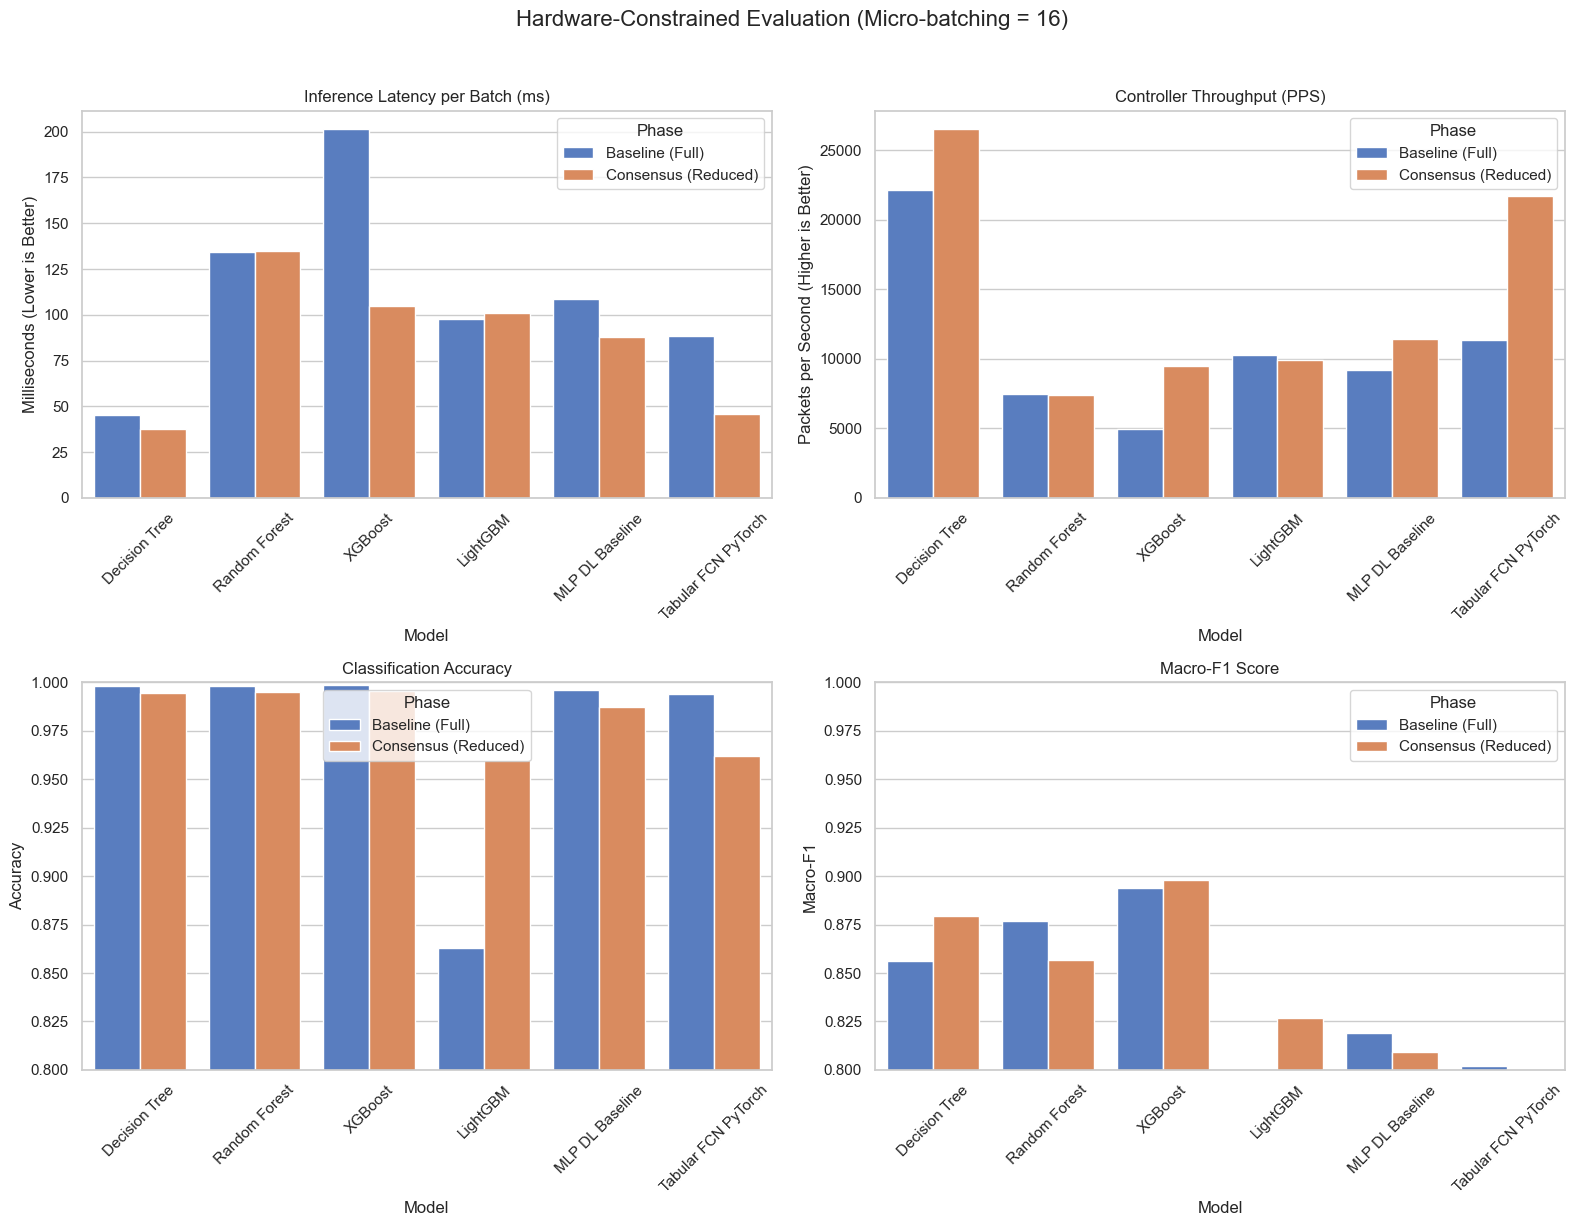

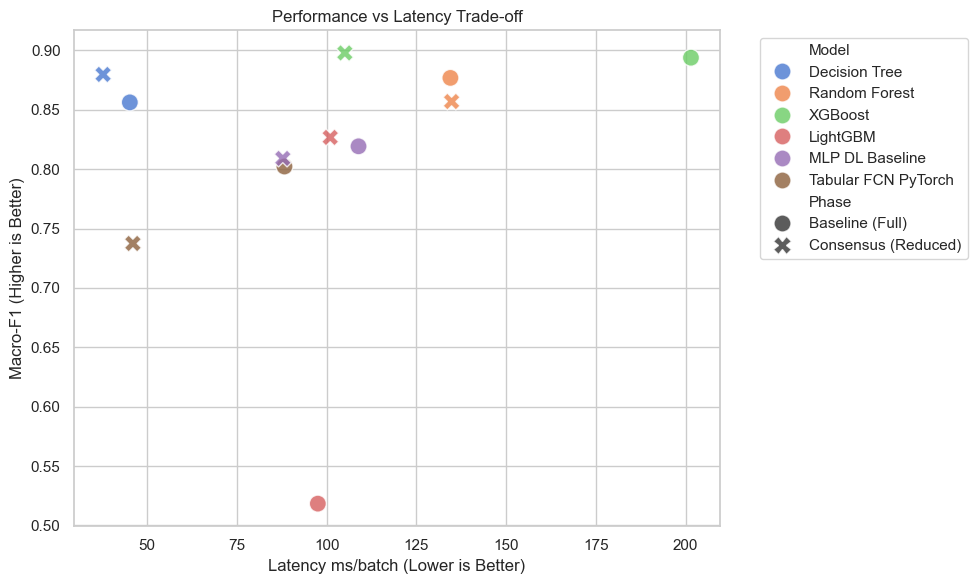


--- Consensus Feature Reduction Impact ---


,Latency Change (%),Throughput Change (%)
Model,,
Decision Tree,-16.50,19.77
LightGBM,3.54,-3.42
MLP DL Baseline,-19.37,24.05
Random Forest,0.25,-0.26
Tabular FCN PyTorch,-47.85,91.76
XGBoost,-47.86,91.80


In [25]:
print("Running local Docker micro-benchmark...")
try:
    subprocess.run(["docker-compose", "up", "--build"], check=True)
    print("Docker benchmark completed successfully.\n")
except Exception as e:
    print(f"Docker execution failed. Make sure Docker Desktop is running. Error: {e}")

# Load and Prepare Results
results_path = CONFIG['ARTIFACTS_DIR'] / 'docker_stress_test_results.csv'

if results_path.exists():
    df_results = pd.read_csv(results_path)
    
    # Print actual columns for debugging
    print(f"Raw CSV columns: {df_results.columns.tolist()}")
    
    # Unify column names
    column_mapping = {
        'Latency_ms': 'Latency_ms_per_batch',
        'Latency/Sample (µs)': 'Latency_ms_per_batch', 
        'Throughput': 'Throughput_PPS',
        'Throughput (PPS)': 'Throughput_PPS',
        'F1_Score': 'Macro-F1',
        'Macro_F1': 'Macro-F1',
        'Accuracy_Score': 'Accuracy'
    }
    df_results.rename(columns=column_mapping, inplace=True)
    
    # Clean up Phase names for the charts
    df_results['Phase'] = df_results['Phase'].replace({
        'Full_Baseline': 'Baseline (Full)', 
        'Full Baseline (Heavy)': 'Baseline (Full)',
        'Reduced_Space': 'Consensus (Reduced)',
        'Reduced (Consensus XAI)': 'Consensus (Reduced)'
    })

    # Display styled summary table
    print("--- Benchmark Summary ---")
    display_df = df_results[['Model', 'Phase', 'Accuracy', 'Macro-F1', 'Throughput_PPS', 'Latency_ms_per_batch']]
    
    display(display_df.style.format({
        'Accuracy': '{:.4f}',
        'Macro-F1': '{:.4f}',
        'Throughput_PPS': '{:.1f}',
        'Latency_ms_per_batch': '{:.2f}'
    }).background_gradient(subset=['Throughput_PPS'], cmap='Greens')
      .background_gradient(subset=['Latency_ms_per_batch'], cmap='OrRd'))

    # Visualization Setup
    sns.set_theme(style="whitegrid", palette="muted")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Hardware-Constrained Evaluation (Micro-batching = 16)', fontsize=16, y=1.02)

    # Plot 1: Latency
    sns.barplot(data=df_results, x='Model', y='Latency_ms_per_batch', hue='Phase', ax=axes[0,0])
    axes[0,0].set_title('Inference Latency per Batch (ms)')
    axes[0,0].set_ylabel('Milliseconds (Lower is Better)')
    axes[0,0].tick_params(axis='x', rotation=45)

    # Plot 2: Throughput
    sns.barplot(data=df_results, x='Model', y='Throughput_PPS', hue='Phase', ax=axes[0,1])
    axes[0,1].set_title('Controller Throughput (PPS)')
    axes[0,1].set_ylabel('Packets per Second (Higher is Better)')
    axes[0,1].tick_params(axis='x', rotation=45)

    # Plot 3: Accuracy
    sns.barplot(data=df_results, x='Model', y='Accuracy', hue='Phase', ax=axes[1,0])
    axes[1,0].set_title('Classification Accuracy')
    axes[1,0].set_ylim(0.8, 1.0)
    axes[1,0].tick_params(axis='x', rotation=45)

    # Plot 4: Macro-F1
    sns.barplot(data=df_results, x='Model', y='Macro-F1', hue='Phase', ax=axes[1,1])
    axes[1,1].set_title('Macro-F1 Score')
    axes[1,1].set_ylim(0.8, 1.0)
    axes[1,1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(CONFIG['FIGURES_DIR'] / 'benchmark_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Trade-off Scatter Plot (Latency vs F1)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_results, 
        x='Latency_ms_per_batch', 
        y='Macro-F1', 
        hue='Model', 
        style='Phase', 
        s=150, 
        alpha=0.8
    )
    plt.title('Performance vs Latency Trade-off')
    plt.xlabel('Latency ms/batch (Lower is Better)')
    plt.ylabel('Macro-F1 (Higher is Better)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(CONFIG['FIGURES_DIR'] / 'tradeoff_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Relative Improvements Calculation
    print("\n--- Consensus Feature Reduction Impact ---")
    try:
        pivot_df = df_results.pivot(index='Model', columns='Phase', values=['Latency_ms_per_batch', 'Throughput_PPS'])
        
        # Calculate percentage changes
        latency_change = ((pivot_df[('Latency_ms_per_batch', 'Consensus (Reduced)')] - 
                           pivot_df[('Latency_ms_per_batch', 'Baseline (Full)')]) / 
                           pivot_df[('Latency_ms_per_batch', 'Baseline (Full)')]) * 100
                           
        throughput_change = ((pivot_df[('Throughput_PPS', 'Consensus (Reduced)')] - 
                              pivot_df[('Throughput_PPS', 'Baseline (Full)')]) / 
                              pivot_df[('Throughput_PPS', 'Baseline (Full)')]) * 100
        
        impact_df = pd.DataFrame({
            'Latency Change (%)': latency_change,
            'Throughput Change (%)': throughput_change
        }).round(2)
        
        display(impact_df)
    except KeyError as e:
        print(f"Skipping relative improvement calculation. Expected pivot keys missing: {e}")

else:
    print(f"Results file not found at {results_path}. Ensure the Docker script ran and saved the output.")
